<a href="https://colab.research.google.com/github/maizoh/Project_Shinshu/blob/main/Project_Shinshu_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt


pd.set_option('display.max_rows', None)

df_2024=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2024.csv",encoding="shift_jis"))
df_2024_selected=pd.DataFrame(df_2024.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

df_2023=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2023.csv",encoding="shift_jis"))
df_2023_selected=pd.DataFrame(df_2023.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

df_2022=pd.DataFrame(pd.read_csv("/content/Medical_Data/MedicalReportPubH_2022.csv",encoding="shift_jis"))
df_2022_selected=pd.DataFrame(df_2022.iloc[:,[3,5,12,14,33,36,38,45,58,59,60,62,64,66,69]])

print(df_2024_selected.columns==df_2023_selected.columns,
df_2022_selected.columns==df_2023_selected.columns,
df_2022_selected.columns==df_2024_selected.columns)
df_2024_selected.columns

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True] [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True] [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True]


Index(['発生曜日', '発生時間帯', '発生場所', '概要', '当事者職種_1', '当事者職種経験（年数）_1',
       '当事者部署配属期間（年数）_1', '事例の内容', '事例の内容.1', '発生要因_当事者の行動に関わる要因',
       '発生要因_ヒューマンファクター', '発生要因_環境・設備機器', '発生要因_その他', '事例の背景要因の概要', '改善策'],
      dtype='object')

In [73]:
df_merged=pd.concat([df_2024_selected,df_2023_selected,df_2022_selected],axis=0,ignore_index=True)
df_merged.to_csv("/content/Medical_Data/df_merged_2.csv")

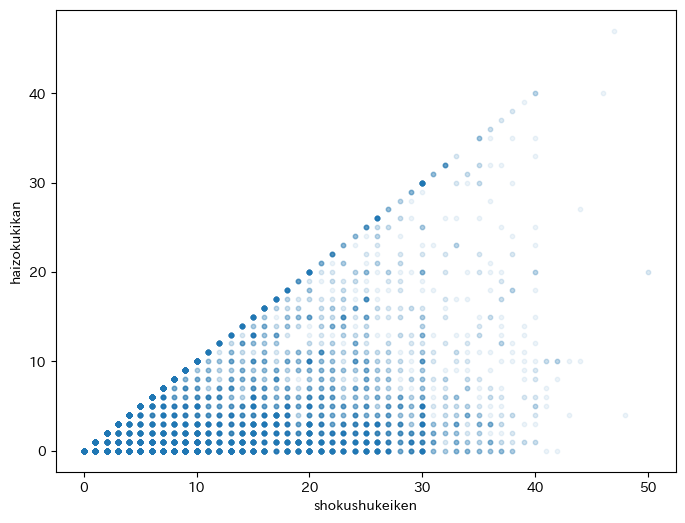

In [74]:
df_clean=df_merged.copy()

df_clean["当事者職種経験（年数）_1"]=df_clean["当事者職種経験（年数）_1"].astype(str).str.replace("年","").astype(int)
df_clean['当事者部署配属期間（年数）_1']=df_clean['当事者部署配属期間（年数）_1'].astype(str).str.replace("年","").astype(int)

df_clean = df_clean[df_clean['当事者職種経験（年数）_1'] >= df_clean['当事者部署配属期間（年数）_1']]

fig,ax=plt.subplots(figsize=(8,6))

x=df_clean["当事者職種経験（年数）_1"]
y=df_clean['当事者部署配属期間（年数）_1']

ax.scatter(x,y,s=10,alpha=0.08)
ax.set_xlabel("shokushukeiken")
ax.set_ylabel("haizokukikan")

plt.show()

薬剤ミスの解像度を高めていく。配属年数ごとのミスの違いとか、経験年数ごとのミスの違いとか

In [75]:
df_merged.head()

,発生曜日,発生時間帯,発生場所,概要,当事者職種_1,当事者職種経験（年数）_1,当事者部署配属期間（年数）_1,事例の内容,事例の内容.1,発生要因_当事者の行動に関わる要因,発生要因_ヒューマンファクター,発生要因_環境・設備機器,発生要因_その他,事例の背景要因の概要,改善策
0,水曜日,14:00〜15:59,救急外来,医療機器等,医師,3年,3年,使用中の点検・管理ミス,リカバリー室にいる患者が処置室へ移動する際に医師がストレッチャーを動かした。その際にナースコ...,確認を怠った,NaN,NaN,NaN,未記入,患者を移動させる際はコードや酸素チューブ、点滴が整理されているか確認をする。
1,金曜日,8:00〜9:59,病室,薬剤,看護師,17年,2年,過剰投与,訪室し検査準備をしていると「今、夕方の薬も一緒に飲んでしまった」と患者より報告を受ける。硝酸...,確認を怠った 患者への説明が不十分であった（怠った） 判断を誤った,NaN,NaN,NaN,CAG施行前に硝酸イソソルビド錠20ｍｇ朝一錠内服予定であった。前日夜勤の看護師が朝の分のみ...,夕食後の分は混乱をまねくため、検査後に手渡す。
2,木曜日,8:00〜9:59,病室,薬剤,看護師,4年,4年,過剰与薬準備,術前内服中止薬を内服した。手術当日の夜勤帯看護師が患者に内服錠数を確認すると、医師指示と異な...,確認を怠った 患者への説明が不十分であった（怠った） 判断を誤った,NaN,NaN,その他,前日受け持ちの看護師が、患者へ内服内容を伝えたが口頭のみで伝えた。内服自己管理だったため、持...,内服自己管理でも、中止薬がある際には口頭のみではなく実際に内服薬を取り出し説明をする。患者の...
3,土曜日,12:00〜13:59,病棟処置室,医療機器等,看護師,26年,3年,使用中の点検・管理ミス,発見時、勤務中のスタッフ全員に確認したが該当者はいなかった。アンプル用のごみ箱は数日分をまと...,確認を怠った 判断を誤った,NaN,その他,NaN,未記入,間違ったごみ処理により、収集時や収集後の処理を担当する者に怪我を負わせるリスクがあることを念...
4,月曜日,6:00〜7:59,病室,薬剤,看護師,1年,1年,その他の与薬に関する内容,麻薬が漏れているのを発見した,観察を怠った,技術・手技が未熟だった,NaN,NaN,・6時20分、患者の病室を訪室すると患者の点滴刺入部 付近のシーツが直径15ｃｍ程度濡れてい...,・補液治療を行っている患者は薬剤に関係なく逆血・刺入部の確認を行い正しく薬剤が投与されている...


In [76]:
!pip install mecab-python3 ipadic networkx japanize-matplotlib

In [77]:
df_kai=df_merged.loc[:,["当事者職種経験（年数）_1","発生要因_ヒューマンファクター","発生要因_当事者の行動に関わる要因","発生要因_環境・設備機器","発生要因_その他","発生場所","当事者部署配属期間（年数）_1","概要"]]

df_kai['当事者職種経験（年数）_1']=df_kai['当事者職種経験（年数）_1'].astype(str).str.replace("00","0").str.replace("年","").astype(int)
df_kai["当事者部署配属期間（年数）_1"]=df_kai["当事者部署配属期間（年数）_1"].astype(str).str.replace("年","").astype(int)
df_kai['発生要因_ヒューマンファクター']=df_kai['発生要因_ヒューマンファクター'].str.split(r'\s+')
df_kai["発生要因_当事者の行動に関わる要因"]=df_kai["発生要因_当事者の行動に関わる要因"].str.split(r"\s+")
df_kai["発生要因_環境・設備機器"]=df_kai["発生要因_環境・設備機器"].str.split(r"\s+")
df_kai["発生要因_その他"]=df_kai["発生要因_その他"].str.split(r"\s+")

bins = [-1, 0, 1, 3, 10, 20, 30,  np.inf]
labels = ["0年目", "1年目", "2〜3年目", "4〜10年目", "11～20年目","21～30年目","31年目以上"]
df_kai["経験年数グループ"] = pd.cut(df_kai['当事者職種経験（年数）_1'], bins=bins, labels=labels)

df_human=df_kai.explode('発生要因_ヒューマンファクター')
df_action=df_kai.explode("発生要因_当事者の行動に関わる要因")
df_env=df_kai.explode("発生要因_環境・設備機器")

In [78]:
cross_table_human=pd.crosstab(df_human["経験年数グループ"],df_human['発生要因_ヒューマンファクター'])

data_ndarray=cross_table_human.values

chi2, p, dof, expected = stats.chi2_contingency(data_ndarray)
print(f"p値: {p:.4f}")

p値: 0.0000


In [79]:
def adjusted_standardized_residuals(cross_table):

      # 1. 通常のカイ2乗検定で「期待度数」を取得
      # ※ cross_table は pd.crosstab() で作った DataFrame
      observed = cross_table.values
      chi2, p, dof, expected = stats.chi2_contingency(observed)

      # 2. 調整済み標準化残差の計算
      n = observed.sum()  # 総サンプル数（16000件）
      row_totals = observed.sum(axis=1, keepdims=True)  # 各行の合計
      col_totals = observed.sum(axis=0, keepdims=True)  # 各列の合計

      # 各セルの分散の分母を計算
      variance = expected * (1 - row_totals / n) * (1 - col_totals / n)

      # 調整済み標準化残差 ＝ (実測度数 - 期待度数) / 💡(分散の平方根)
      adjusted_residuals = (observed - expected) / np.sqrt(variance)

      # 3. DataFrameの形に戻す
      df_residuals = pd.DataFrame(
          adjusted_residuals, index=cross_table.index, columns=cross_table.columns
      )

      return df_residuals

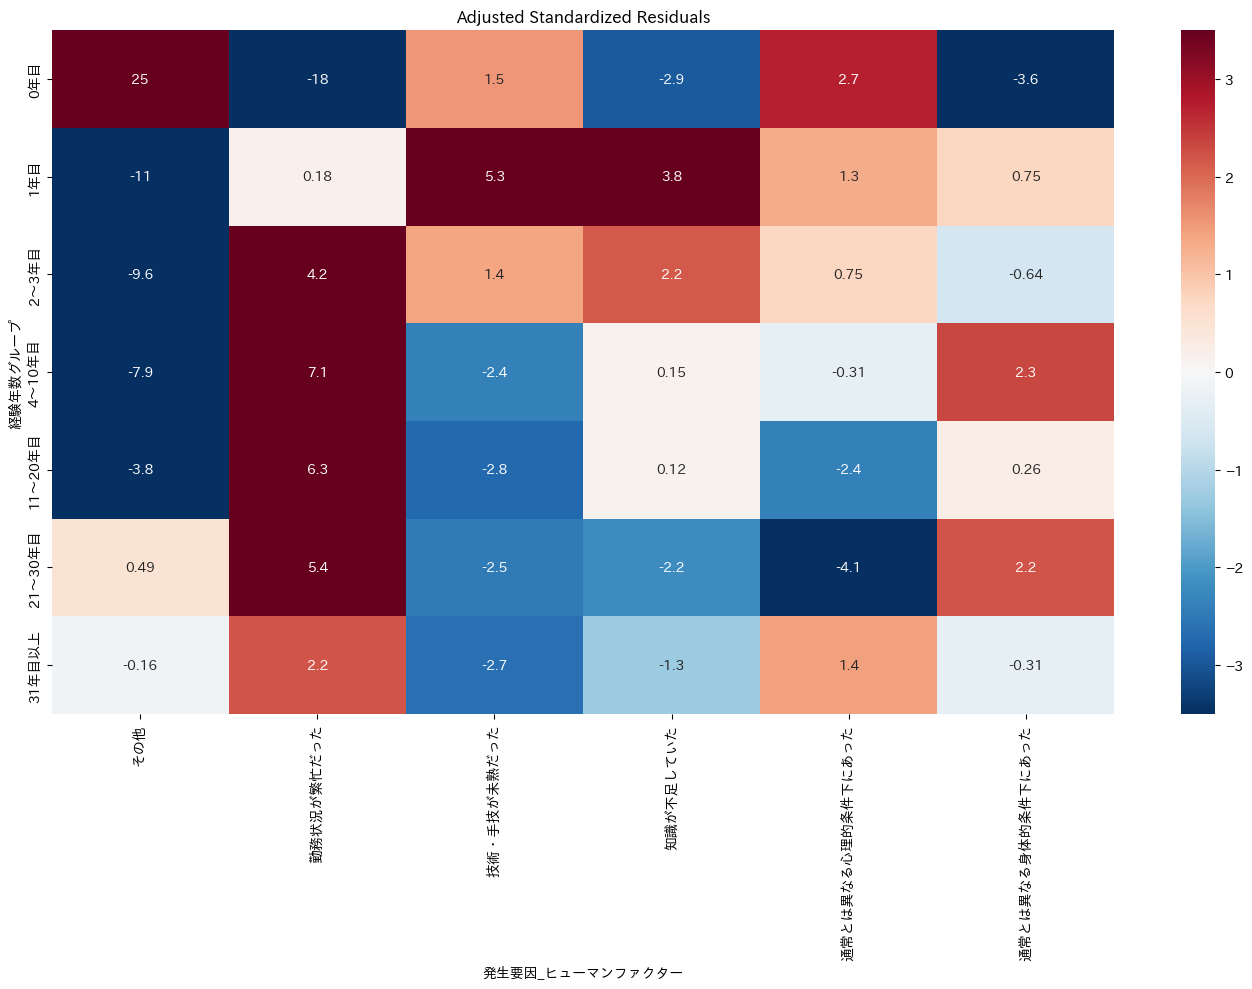

In [84]:
df_residuals_human=adjusted_standardized_residuals(cross_table_human)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))

# 0を中心に、プラス（赤）とマイナス（青）が綺麗に分かれるカラーマップ「RdBu_r」を使用
# vmin, vmaxを±3.3くらいに設定すると、目立つ場所だけが濃くなるよ
sns.heatmap(
    df_residuals_human,
    annot=True,  # 件数が多いならFalse、見たいならTrue
    cmap="RdBu_r",
    center=0,
    vmin=-3.5,
    vmax=3.5,
)

plt.title("Adjusted Standardized Residuals")
plt.tight_layout()
plt.show()

0年のその他、ベテランは通常と異なる状況下で起きる傾向が高い

In [81]:
cross_table_action=pd.crosstab(df_action["経験年数グループ"],df_action["発生要因_当事者の行動に関わる要因"])
df_residuals_action=adjusted_standardized_residuals(cross_table_action)

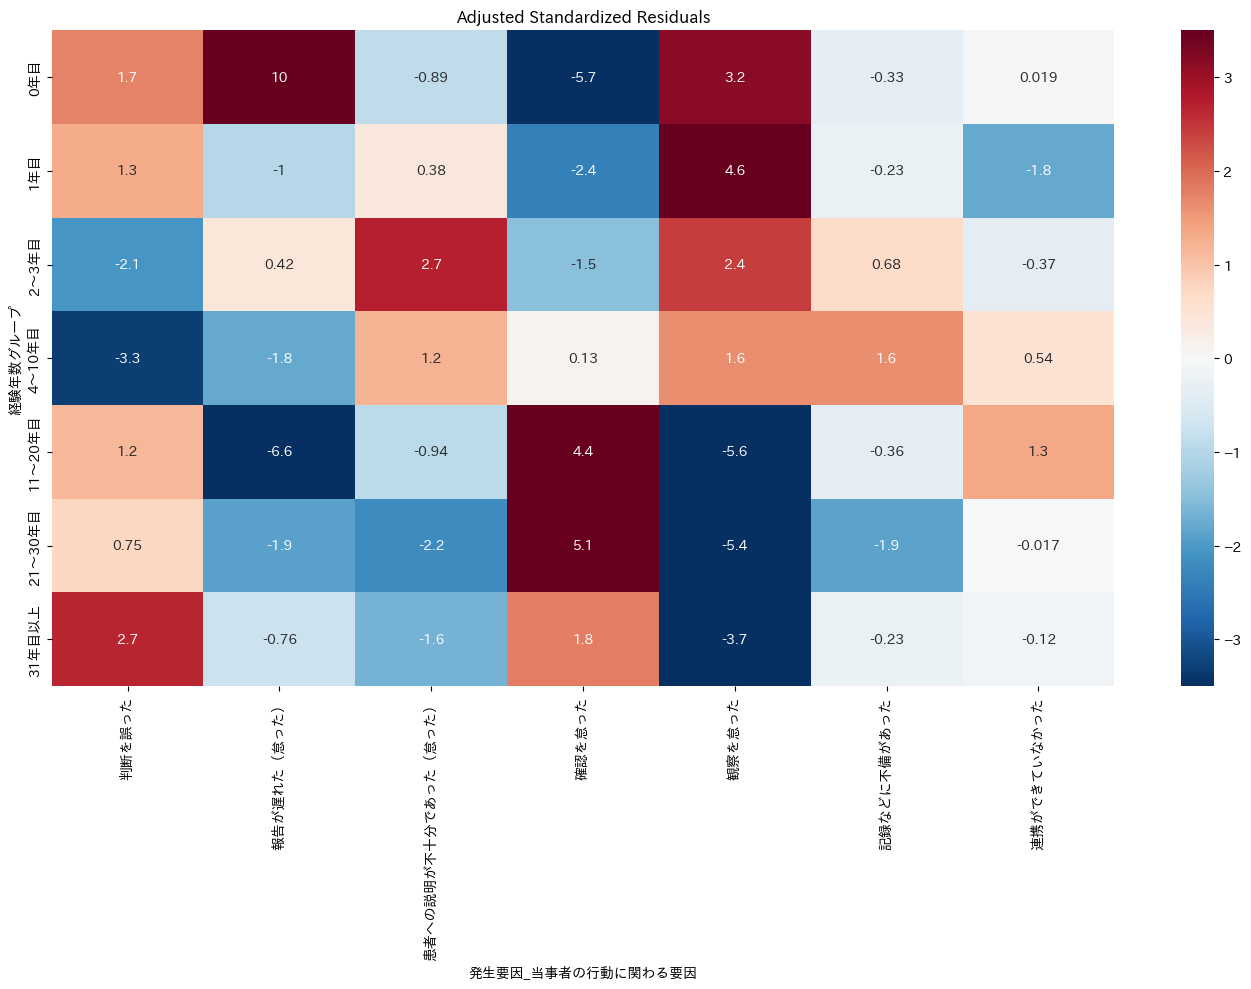

In [83]:
plt.figure(figsize=(14, 10))

# 0を中心に、プラス（赤）とマイナス（青）が綺麗に分かれるカラーマップ「RdBu_r」を使用
# vmin, vmaxを±3.3くらいに設定すると、目立つ場所だけが濃くなるよ
sns.heatmap(
    df_residuals_action,
    annot=True,  # 件数が多いならFalse、見たいならTrue
    cmap="RdBu_r",
    center=0,
    vmin=-3.5,
    vmax=3.5,
)

plt.title("Adjusted Standardized Residuals")
plt.tight_layout()
plt.show()